In [ ]:
##----1. Intilze the Chat_Bot ------------
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()
os.environ["GROQ_API_KEY"] =  os.getenv("GROQ_API_KEY")
print("GROQ_API_KEY : ", os.getenv("GROQ_API_KEY"))
model = init_chat_model("groq:llama-3.1-8b-instant")
response = model.invoke("Hi")
response

In [ ]:
###----Build a Basic Chat Bot using LangGraph (GRAPH API)----

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages 
    #  Add_message is used to add messages to the graph 
from typing_extensions import TypedDict
    #  TypedDict is used to define the structure of the messages in the graph
from typing import Annotated
    #  Annotated is used to add metadata to the messages in the graph


In [ ]:
# 2.  -----State Definition----------------
class State(TypedDict):
    """In the Annotated  defines how this state key should be updated
    (in the case of messages, it append the new message to the list of messages)"""
    messages:Annotated[list, add_messages]


In [ ]:
# 3. -------Node Function-------------
def chat_bot_response(state:State):
    return {"messages":[model.invoke(state["messages"])]}

In [ ]:
# 4. ----Building the graph-----
graph_builder = StateGraph(State)
#----adding nodes and edges to the graph----
graph_builder.add_node("chat_bot_response", chat_bot_response)
graph_builder.add_edge(START, "chat_bot_response")
graph_builder.add_edge("chat_bot_response", END)

#----Compiling the graph-------
graph = graph_builder.compile()
print(graph)


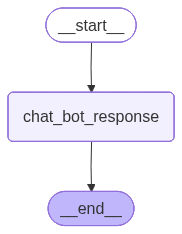

In [20]:
# 5. ----------Visualize the graph----------
from IPython.display import Image , display
try:    
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Error visualizing the graph: ", e)


In [ ]:
response = graph.invoke({"messages":[{"role":"user", "content":"Hello, how are you?"}]})

In [21]:
response["messages"][-1].content

"I'm functioning properly, thanks for asking. I'm a large language model, so I don't have emotions like humans do, but I'm here to help you with any questions or topics you'd like to discuss. How can I assist you today?"